In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
def get_acc(path: str) -> float:
    df = pd.read_csv(path, sep="\t", index_col=0)
    total = df.values.sum()
    assert total == 20000
    correct = np.trace(df.values)
    return 100 * correct / total

def get_dice(path: str) -> float:
    dice = pd.read_csv(path, sep='\t', header=None, names=["mean", "std"])
    return 100 * dice['mean'].values[0]

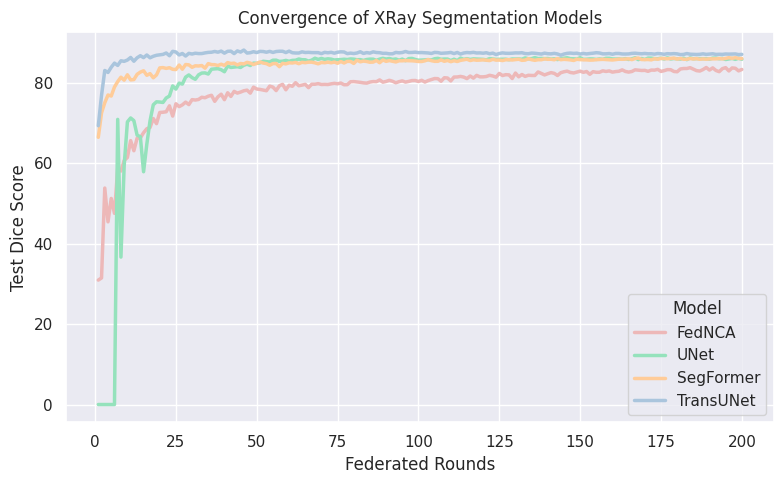

In [3]:
x = range(0, 200)
y = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/XRayMimic200_5_42_0.25_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_unet/checkpoint_val/dice_{i}.txt") for i in x]
y2 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/XRayMimic200_5_42_0.25_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_new_mednca/checkpoint_val/dice_{i}.txt") for i in x]
y4 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/XRayMimic200_5_42_0.25_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_segformer/checkpoint_val/dice_{i}.txt") for i in x]
y5 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/XRayMimic200_5_42_0.25_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_transunet_b16/checkpoint_val/dice_{i}.txt") for i in x]
x = [x+1 for x in x]  # epochs start at 1


df = pd.DataFrame({
    "epoch": list(x),
    "FedNCA": y2,
    "UNet": y,
    "SegFormer": y4,
    "TransUNet": y5,
})

df_long = df.melt(
    id_vars="epoch",
    var_name="Model",
    value_name="Dice"
)

brightness_factor = 1.0
palette = {
    "FedNCA": brightness_factor * np.array((237/255, 184/255, 184/255)),
    "UNet": brightness_factor * np.array((149/255, 226/255, 188/255)),
    "TransUNet": brightness_factor * np.array((170/255, 197/255, 221/255)),
    "SegFormer":brightness_factor * np.array((255/255, 204/255, 153/255))
}

sns.set_theme(
    rc={
        "lines.linewidth": 2.5,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_long,
    x="epoch",
    y="Dice",
    hue="Model",
    linewidth=2.5,
    palette=palette,
)
plt.ylabel("Test Dice Score")
plt.xlabel("Federated Rounds")
plt.legend(title="Model")
plt.title("Convergence of XRay Segmentation Models")
plt.tight_layout()
plt.savefig("./plots/convergence_xray.pdf", bbox_inches='tight')

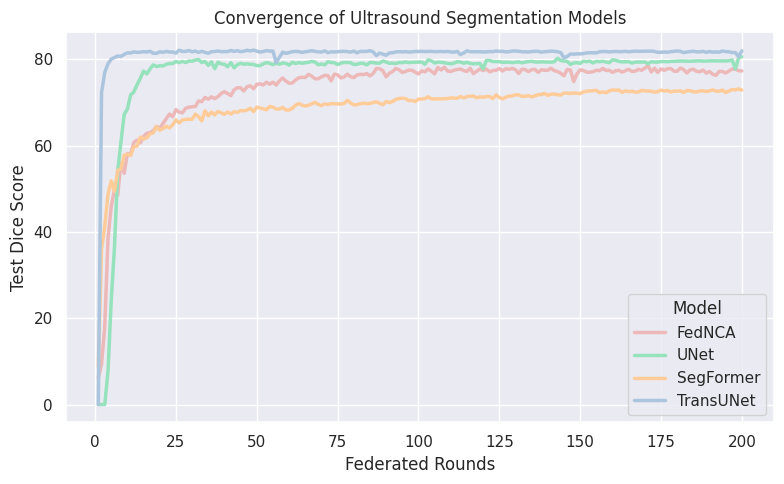

In [4]:
x = range(0, 200)
y = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/fetalAbdominal_5_42_0.7_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_unet/checkpoint_val/dice_{i}.txt") for i in x]
y2 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/fetalAbdominal_5_42_0.7_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_new_mednca/checkpoint_val/dice_{i}.txt") for i in x]
y3 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/fetalAbdominal_5_42_0.7_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_new_mednca_nobn/checkpoint_val/dice_{i}.txt") for i in x]
y4 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/fetalAbdominal_5_42_0.7_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_segformer/checkpoint_val/dice_{i}.txt") for i in x]
y5 = [get_dice(f"/local/scratch/mikonsta/fednca_journal/workingdir4/fetalAbdominal_5_42_0.7_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_transunet_b16/checkpoint_val/dice_{i}.txt") for i in x]
x = [x+1 for x in x]  # epochs start at 1


df = pd.DataFrame({
    "epoch": list(x),
    "FedNCA": y2,
    "UNet": y,
    # "MedNCA w/o BN": y3,
    "SegFormer": y4,
    "TransUNet": y5,
})

df_long = df.melt(
    id_vars="epoch",
    var_name="Model",
    value_name="Dice"
)

brightness_factor = 1.0
palette = {
    "FedNCA": brightness_factor * np.array((237/255, 184/255, 184/255)),
    "UNet": brightness_factor * np.array((149/255, 226/255, 188/255)),
    "TransUNet": brightness_factor * np.array((170/255, 197/255, 221/255)),
    "SegFormer":brightness_factor * np.array((255/255, 204/255, 153/255))
}

sns.set_theme(
    rc={
        "lines.linewidth": 2.5,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_long,
    x="epoch",
    y="Dice",
    hue="Model",
    linewidth=2.5,
    palette=palette,
)
plt.ylabel("Test Dice Score")
plt.xlabel("Federated Rounds")
plt.legend(title="Model")
plt.title("Convergence of Ultrasound Segmentation Models")
plt.tight_layout()
plt.savefig("./plots/convergence_ultrasound.pdf", bbox_inches='tight')

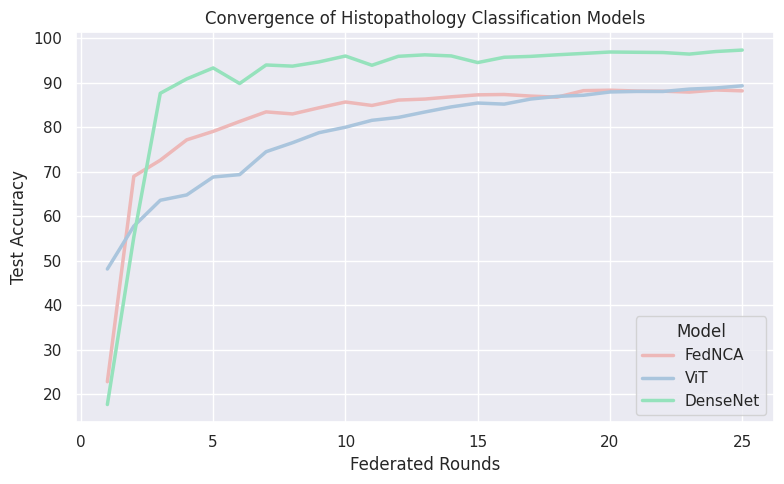

In [5]:
x = range(0, 25)
y = [get_acc(f"/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_maxmednca_nobn/checkpoint_val/dice_{i}.txt") for i in x]
y2 = [get_acc(f"/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_vit/checkpoint_val/dice_{i}.txt") for i in x]
y3 = [get_acc(f"/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_densenet/checkpoint_val/dice_{i}.txt") for i in x]
y4 = [get_acc(f"/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_vit4sgd/checkpoint_val/dice_{i}.txt") for i in x]
x = [x+1 for x in x]  # epochs start at 1


df = pd.DataFrame({
    "epoch": list(x),
    "FedNCA": y,
    "ViT": y4,
    "DenseNet": y3,
})

df_long = df.melt(
    id_vars="epoch",
    var_name="Model",
    value_name="Dice"
)

brightness_factor = 1.0
palette = {
    "FedNCA": brightness_factor * np.array((237/255, 184/255, 184/255)),
    "DenseNet": brightness_factor * np.array((149/255, 226/255, 188/255)),
    "ViT": brightness_factor * np.array((170/255, 197/255, 221/255)),
}

sns.set_theme(
    rc={
        "lines.linewidth": 2.5,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_long,
    x="epoch",
    y="Dice",
    hue="Model",
    linewidth=2.5,
    palette=palette,
)
plt.ylabel("Test Accuracy")
plt.xlabel("Federated Rounds")
plt.legend(title="Model")
plt.title("Convergence of Histopathology Classification Models")
plt.tight_layout()
plt.savefig("./plots/convergence_crc.pdf", bbox_inches='tight')